In [28]:
# Importações de bibliotecas
from sklearn.metrics import confusion_matrix, precision_score, accuracy_score, recall_score, f1_score, classification_report, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

print("Importações concluídas com sucesso!")

Importações concluídas com sucesso!


In [21]:
# Carregamento do dataset e funções auxiliares
def carregar_csv(nome_arquivo = "flights_delays_120.csv"):
  """
  Carrega o arquivo CSV informado.
  Verifica se o arquivo existe antes de tentar ler.
  """
  if os.path.exists(nome_arquivo):
    print(f"Arquivo '{nome_arquivo}' encontrado. Carregando dados...")
    return pd.read_csv(nome_arquivo)
  else:
    print(f"Erro: Arquivo '{nome_arquivo}' não encontrado.")

def coluna_alvo(dados):
  """
  Detecta automaticamente a coluna alvo do dataframe.
  Procura por nomes comuns de coluna alvo.
  """
  candidatos = ["delayed", "atrasos", "alvo", "target", "y"]
  for c in candidatos:
    if c in dados.columns:
      print(f"Coluna alvo detectada: {c}.")
      return c

  # Se não encontrar nenhuma, levanta um erro
  print(f"Erro: Nenhuma coluna alvo (como 'delayed' ou 'atraso') foi encontrada.")
  raise KeyError("Coluna alvo não encontraada.")

In [25]:
# Preparando os dados
dados = carregar_csv()
alvo = coluna_alvo(dados)

# Separando X (features) e Y (alvo)
y = dados[alvo]
x = dados.drop(columns=[alvo])

# Separando colunas categóricas e numéricas
cat = [c for c in x.columns if x[c].dtype == "object"]
num = [c for c in x.columns if c not in cat]

print(f"Colunas categóricas identificadas: {cat}")
print(f"Colunas numéricas identificadas: {num}")

# Dividindo em treino e teste
x_treino, x_teste, y_treino, y_teste = train_test_split(
    x, y,
    test_size=0.25,
    stratify=y,
    random_state=7
)

print(f"Dados divididos: {len(y_treino)} para treino, {len(y_teste)} para teste")

Arquivo 'flights_delays_120.csv' encontrado. Carregando dados...
Coluna alvo detectada: delayed.
Colunas categóricas identificadas: ['airline', 'origin', 'destination', 'weather']
Colunas numéricas identificadas: ['departure_hour', 'day_of_week']
Dados divididos: 90 para treino, 30 para teste


In [27]:
# Pré-processador e Pipeline do modelo
preprocessador = ColumnTransformer([
    ("categoricas", OneHotEncoder(handle_unknown="ignore"), cat),
    ("numericas", "passthrough", num)
])

# Modelo XGBoost
modelo = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=7
)

pipeline = Pipeline([
    ("prep", preprocessador),
    ("xgb", modelo)
])

# Treinando o modelo
print("Iniciando o treinamento do modelo XGBoost...")
pipeline.fit(x_treino, y_treino)
print("Modelo treinado com sucesso!")


Iniciando o treinamento do modelo XGBoost...
Modelo treinado com sucesso!


In [33]:
# Predição e Métricas de desempenho
probas = pipeline.predict_proba(x_teste)[:,1]

# Convertendo para uma classe binária
threshold = 0.5

y_pred = (probas >= threshold).astype(int)

# Matriz de confusão
cm = confusion_matrix(y_teste, y_pred)
print("--- Métricas de Desempenho (Threshold 0.5) ---")
print(f"Matriz de confusão:\n{cm}")

# Métricas principais
print(f"Acurácia: {accuracy_score(y_teste, y_pred):.4f}")
print(f"Precisão: {precision_score(y_teste, y_pred, zero_division=0):.4f}")
print(f"Recall (sensibilidade): {recall_score(y_teste, y_pred, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_teste, y_pred, zero_division=0):.4f}")

# Relatório de classificação
print(f"\n--- Relatório de Classificação ---\n{classification_report(y_teste, y_pred)}")



--- Métricas de Desempenho (Threshold 0.5) ---
Matriz de confusão:
[[17  0]
 [ 0 13]]
Acurácia: 1.0000
Precisão: 1.0000
Recall (sensibilidade): 1.0000
F1-Score: 1.0000

--- Relatório de Classificação ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30




--- Curva ROC ---
AUC (área sob curva): 1.0000


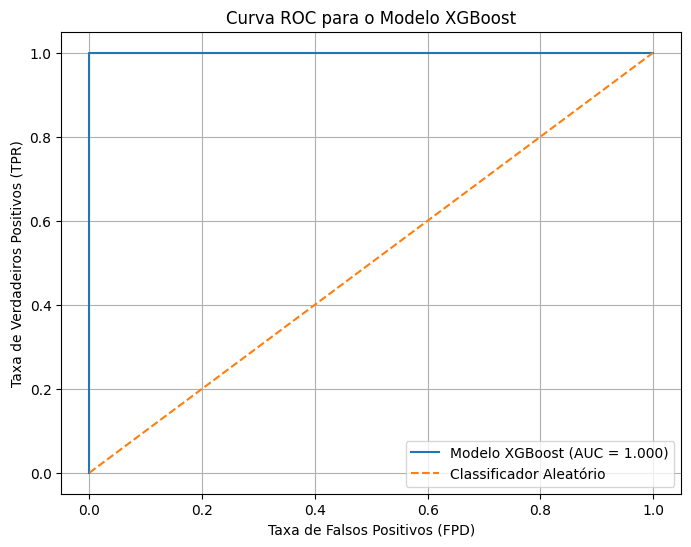

In [32]:
# Curva ROC e AUC
fpr, tpr, thresholds = roc_curve(y_teste, probas)
auc = roc_auc_score(y_teste, probas)

print(f"\n--- Curva ROC ---\nAUC (área sob curva): {auc:.4f}")

# Plotando os dados em um gráfico
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Modelo XGBoost (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Classificador Aleatório")

plt.xlabel("Taxa de Falsos Positivos (FPD)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Curva ROC para o Modelo XGBoost")
plt.legend()
plt.grid(True)
plt.show()